# Parameters

In [1]:
# ---------------------------------------------------------
# 1. Parameter Setup
# ---------------------------------------------------------
mu = 1.0              # Service rate
theta = 0.5           # Abandonment rate
c_s = 10.0            # Staffing cost coefficient
h_cost = 2.0          # Polynomial holding cost coefficient
p_power = 2.0         # Polynomial holding cost power
c_a = 2.0             # Abandonment cost

lambda_mean = 20.0    # Baseline arrival rate     
kappa = 1.0           # Mean-reversion rate
sigma = 1.0           # Volatility parameter
alpha = 0.5           # Dispersion scaling

# Solve HJB

Dynamically calculated HJB Grid Parameters:
y_min: -8.0
y_max: 8.0
ny: 107
u_min: -2.83
u_max: 2.83
nu: 39
beta_min: -8.0
beta_max: 12.0
n_beta: 135
dy: 0.1509
du: 0.1489
Converged after 4521 iterations.
Estimated Long-Run Average Cost Rate (gamma) = 1951.3385


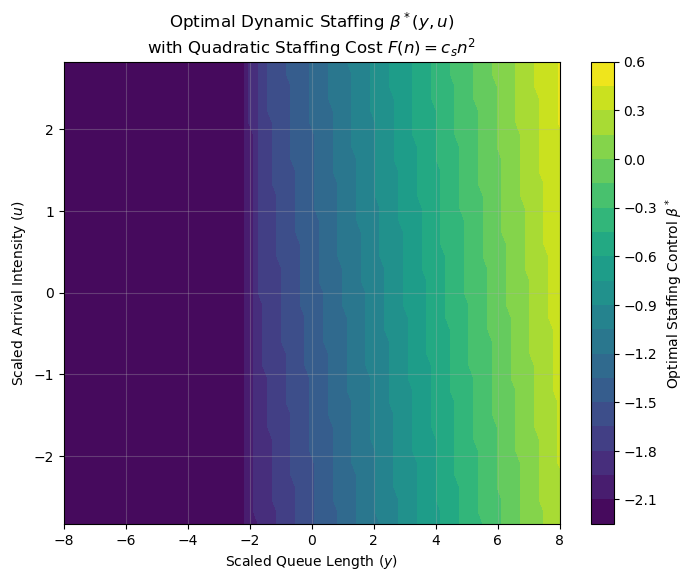

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 2. Derived Multipliers & Cost Function
# ---------------------------------------------------------
scale_exp = (alpha + 1) / 2.0

# Multipliers for holding and abandonment
cost_hold_mult = h_cost * (lambda_mean ** (scale_exp * p_power))
cost_abnd_mult = c_a * theta * (lambda_mean ** scale_exp)

# Diffusion variance coefficients
D_y = lambda_mean ** (-alpha)
D_u = (sigma ** 2) / 2.0

# Define the quadratic physical staffing cost F(n) = c_s * n^2
def F_tilde_convex_physical(beta):
    # Calculate physical servers 'n' based on the staffing rule
    n = (lambda_mean + beta * (lambda_mean ** scale_exp)) / mu
    return c_s * (n ** 2)

active_F_tilde = F_tilde_convex_physical

def generate_hjb_grid_params(kappa, sigma, mu, theta, Z=4.0, target_step=0.15):
    """
    Generates dynamic grid parameters for the diffusion limit HJB equation.
    """
    # 1. Arrival Intensity Fluctuation Bounds (u)
    std_u = np.sqrt((sigma ** 2) / (2 * kappa))
    u_max = Z * std_u
    u_min = -u_max
    
    # 2. Queue Length Fluctuation Bounds (y)
    min_rate = min(mu, theta) if theta > 0 else mu
    std_y_approx = np.sqrt(1.0 / min_rate + (sigma**2) / (2 * kappa * (min_rate**2)))
    y_max = Z * std_y_approx
    y_min = -y_max
    
    # 3. Action Space Bounds (beta)
    # We allow negative bounds here because quadratic costs heavily penalize overstaffing, 
    # making deliberate understaffing optimal in some states.
    beta_min = -Z * std_y_approx * mu 
    beta_max = max(10.0, mu * y_max * 1.5) 
    
    # 4. Grid Resolutions
    ny = int(np.ceil((y_max - y_min) / target_step)) | 1
    nu = int(np.ceil((u_max - u_min) / target_step)) | 1
    n_beta = int(np.ceil((beta_max - beta_min) / target_step)) | 1
    
    return {
        "y_min": round(y_min, 2), "y_max": round(y_max, 2), "ny": ny,
        "u_min": round(u_min, 2), "u_max": round(u_max, 2), "nu": nu,
        "beta_min": round(beta_min, 2), "beta_max": round(beta_max, 2), "n_beta": n_beta,
        "dy": round((y_max - y_min) / (ny - 1), 4),
        "du": round((u_max - u_min) / (nu - 1), 4)
    }

params = generate_hjb_grid_params(kappa=kappa, sigma=sigma, mu=mu, theta=theta)
print("Dynamically calculated HJB Grid Parameters:")
for key, val in params.items():
    print(f"{key}: {val}")

# ---------------------------------------------------------
# 3. Grid Discretization
# ---------------------------------------------------------
ny, nu = params['ny'], params['nu']
y_min, y_max = params['y_min'], params['y_max']
u_min, u_max = params['u_min'], params['u_max']

y_grid = np.linspace(y_min, y_max, ny)
u_grid = np.linspace(u_min, u_max, nu)
dy = y_grid[1] - y_grid[0]
du = u_grid[1] - u_grid[0]
Y, U = np.meshgrid(y_grid, u_grid, indexing='ij')

# Action space (Staffing perturbation beta)
n_beta = params['n_beta']
beta_min, beta_max = params['beta_min'], params['beta_max']
beta_grid = np.linspace(beta_min, beta_max, n_beta)

# Expand grids for vectorized operations: shape (ny, nu, n_beta)
Y_ext = Y[:, :, np.newaxis]
U_ext = U[:, :, np.newaxis]
B_ext = beta_grid[np.newaxis, np.newaxis, :]

# ---------------------------------------------------------
# 4. Precompute Drifts and Costs
# ---------------------------------------------------------
# Queue overload state: (y - beta/mu)
overload = Y_ext - (B_ext / mu)
pos_overload = np.maximum(overload, 0)   # (y - beta/mu)^+
neg_overload = np.maximum(-overload, 0)  # (beta/mu - y)^+

# Drifts (b_y, b_u)
b_y = U_ext - B_ext + mu * neg_overload - theta * pos_overload
b_u = -kappa * U_ext

# Evaluate the chosen staffing cost function over the 3D beta grid
staffing_cost_grid = active_F_tilde(B_ext)

# Objective cost function L(y, u, beta)
cost_matrix = (staffing_cost_grid + 
               cost_hold_mult * (pos_overload ** p_power) + 
               cost_abnd_mult * pos_overload)

# Time step (CFL condition for stability)
max_drift_y = np.max(np.abs(b_y))
max_drift_u = np.max(np.abs(b_u))
dt = 0.9 / (max_drift_y/dy + max_drift_u/du + 2*D_y/(dy**2) + 2*D_u/(du**2))

# ---------------------------------------------------------
# 5. Relative Value Iteration (Upwind Finite Differences)
# ---------------------------------------------------------
V = np.zeros((ny, nu))
tol = 1e-5
max_iter = 50000

for it in range(max_iter):
    # Forward and backward differences
    V_y_fw = np.roll(V, -1, axis=0) - V
    V_y_bw = V - np.roll(V, 1, axis=0)
    V_u_fw = np.roll(V, -1, axis=1) - V
    V_u_bw = V - np.roll(V, 1, axis=1)
    
    # Enforce Neumann boundary conditions (zero derivative)
    V_y_fw[-1, :] = 0; V_y_bw[0, :] = 0
    V_u_fw[:, -1] = 0; V_u_bw[:, 0] = 0
    
    # Second derivatives (central difference)
    V_yy = np.roll(V, -1, axis=0) - 2*V + np.roll(V, 1, axis=0)
    V_uu = np.roll(V, -1, axis=1) - 2*V + np.roll(V, 1, axis=1)
    V_yy[0, :] = 0; V_yy[-1, :] = 0
    V_uu[:, 0] = 0; V_uu[:, -1] = 0
    
    # Scale by grid steps
    V_y_fw_ext = V_y_fw[:, :, np.newaxis] / dy
    V_y_bw_ext = V_y_bw[:, :, np.newaxis] / dy
    V_u_fw_ext = V_u_fw[:, :, np.newaxis] / du
    V_u_bw_ext = V_u_bw[:, :, np.newaxis] / du
    V_yy_ext = V_yy[:, :, np.newaxis] / (dy**2)
    V_uu_ext = V_uu[:, :, np.newaxis] / (du**2)
    
    # Upwind Scheme: multiply drift by correct gradient
    H_y = np.where(b_y > 0, b_y * V_y_fw_ext, b_y * V_y_bw_ext)
    H_u = np.where(b_u > 0, b_u * V_u_fw_ext, b_u * V_u_bw_ext)
    
    # Evaluate Hamiltonian for all betas
    H = cost_matrix + H_y + H_u + D_y * V_yy_ext + D_u * V_uu_ext
    
    # Minimize over beta
    min_idx = np.argmin(H, axis=2)
    H_min = np.min(H, axis=2)
    
    # Euler step
    V_new = V + dt * H_min
    
    # Relative anchoring to prevent divergence
    gamma = V_new[ny//2, nu//2]
    V_new = V_new - gamma
    
    # Check convergence
    max_diff = np.max(np.abs(V_new - V))
    V = V_new.copy()
    
    if max_diff < tol:
        print(f"Converged after {it} iterations.")
        # Because active_F_tilde computes the total physical cost c_s * n^2, 
        # gamma/dt already represents the full long-run average cost.
        original_gamma = gamma / dt 
        print(f"Estimated Long-Run Average Cost Rate (gamma) = {original_gamma:.4f}")
        optimal_beta = beta_grid[min_idx]
        break

# ---------------------------------------------------------
# 6. Visualization
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
cp = plt.contourf(Y, U, optimal_beta, levels=20, cmap='viridis')
plt.colorbar(cp, label='Optimal Staffing Control $\\beta^*$')
plt.title('Optimal Dynamic Staffing $\\beta^*(y, u)$\nwith Quadratic Staffing Cost $F(n) = c_s n^2$')
plt.xlabel('Scaled Queue Length ($y$)')
plt.ylabel('Scaled Arrival Intensity ($u$)')
plt.grid(True, alpha=0.3)
plt.show()

--- HJB Verification ---
Max residual error (interior):  1.660409e-03
Mean residual error (interior): 5.317770e-04


<>:69: SyntaxWarning: invalid escape sequence '\g'
<>:69: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_711321/2047187832.py:69: SyntaxWarning: invalid escape sequence '\g'
  plt.colorbar(cp_res, label='Absolute HJB Residual $|RHS - \gamma|$')


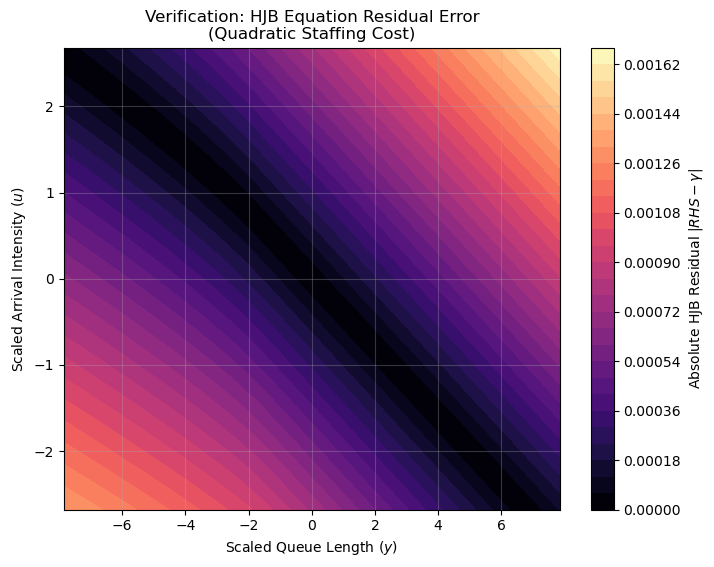

In [3]:
# ---------------------------------------------------------
# 7. Verification: Substitute back into the HJB Equation
# ---------------------------------------------------------

# Calculate spatial derivatives of the converged value function V
V_y_fw = (np.roll(V, -1, axis=0) - V) / dy
V_y_bw = (V - np.roll(V, 1, axis=0)) / dy
V_u_fw = (np.roll(V, -1, axis=1) - V) / du
V_u_bw = (V - np.roll(V, 1, axis=1)) / du

# Neumann boundary conditions for first derivatives
V_y_fw[-1, :] = 0; V_y_bw[0, :] = 0
V_u_fw[:, -1] = 0; V_u_bw[:, 0] = 0

# Second derivatives (central difference)
V_yy = (np.roll(V, -1, axis=0) - 2*V + np.roll(V, 1, axis=0)) / (dy**2)
V_uu = (np.roll(V, -1, axis=1) - 2*V + np.roll(V, 1, axis=1)) / (du**2)
V_yy[0, :] = 0; V_yy[-1, :] = 0
V_uu[:, 0] = 0; V_uu[:, -1] = 0

# Recalculate states specific to the optimal policy beta*
opt_overload = Y - (optimal_beta / mu)
opt_pos_overload = np.maximum(opt_overload, 0)
opt_neg_overload = np.maximum(-opt_overload, 0)

# Drifts under optimal policy
b_y_opt = U - optimal_beta + mu * opt_neg_overload - theta * opt_pos_overload
b_u_opt = -kappa * U

# Running cost under optimal policy
# UPDATED: Use the dynamically assigned active_F_tilde function
cost_opt = (active_F_tilde(optimal_beta) + 
            cost_hold_mult * (opt_pos_overload ** p_power) + 
            cost_abnd_mult * opt_pos_overload)

# Upwind scheme for the generator (matching the solver logic)
H_y_opt = np.where(b_y_opt > 0, b_y_opt * V_y_fw, b_y_opt * V_y_bw)
H_u_opt = np.where(b_u_opt > 0, b_u_opt * V_u_fw, b_u_opt * V_u_bw)

# Generator G_Y applied to V
generator_opt = H_y_opt + H_u_opt + D_y * V_yy + D_u * V_uu

# Right-Hand Side of the HJB Equation
HJB_RHS = cost_opt + generator_opt

# The estimated continuous-time gamma (matches the reported cost)
gamma_rate = gamma / dt

# Calculate the absolute residual error
# We exclude the outer boundaries (slice 1:-1) because the artificial Neumann 
# boundary conditions create numerical artifacts at the exact edges.
interior = slice(1, -1)
residual = np.abs(HJB_RHS - gamma_rate)

max_error = np.max(residual[interior, interior])
mean_error = np.mean(residual[interior, interior])

print("--- HJB Verification ---")
print(f"Max residual error (interior):  {max_error:.6e}")
print(f"Mean residual error (interior): {mean_error:.6e}")

# ---------------------------------------------------------
# 8. Plot the Residual Error
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
# Plotting the interior to avoid boundary artifact distortion
cp_res = plt.contourf(Y[interior, interior], U[interior, interior], 
                      residual[interior, interior], levels=30, cmap='magma')
plt.colorbar(cp_res, label='Absolute HJB Residual $|RHS - \gamma|$')
plt.title('Verification: HJB Equation Residual Error\n(Quadratic Staffing Cost)')
plt.xlabel('Scaled Queue Length ($y$)')
plt.ylabel('Scaled Arrival Intensity ($u$)')
plt.grid(True, alpha=0.3)
plt.show()

# MDP

<>:189: SyntaxWarning: invalid escape sequence '\ '
<>:200: SyntaxWarning: invalid escape sequence '\g'
<>:189: SyntaxWarning: invalid escape sequence '\ '
<>:200: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_711321/3301568740.py:189: SyntaxWarning: invalid escape sequence '\ '
  print(f"{'X \ I':<8}" + "".join([f"{I_val:>6.1f}" for I_val in I_grid]))
/tmp/ipykernel_711321/3301568740.py:200: SyntaxWarning: invalid escape sequence '\g'
  plt.ylabel('Long-Run Average Cost ($\gamma$)')


Generated MDP Parameters:
(349, 68, 35, 0.01, 46.749612199056884)
Starting Policy Iteration...
Converged in 4 iterations.
Optimal Long-Run Average Cost (Gamma): 1927.2531

Optimal Staffing Policy (n servers):
X \ I      0.0   1.4   2.8   4.1   5.5   6.9   8.3   9.6  11.0  12.4  13.8  15.1  16.5  17.9  19.3  20.6  22.0  23.4  24.8  26.1  27.5  28.9  30.3  31.6  33.0  34.4  35.8  37.1  38.5  39.9  41.3  42.6  44.0  45.4  46.7
----------------------------------------
0            0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0
1            1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1
2            2     2     2     2     2     2     2     2     2     2     2     2     2     2 

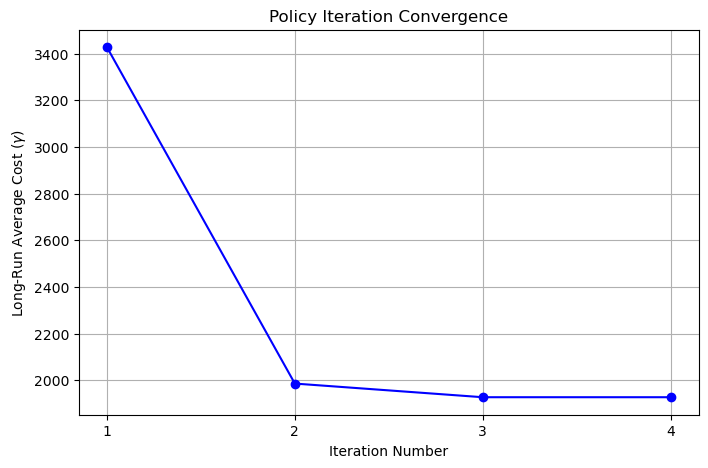

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import math

def calculate_hyperparameters(lambda_mean, mu, theta, kappa, sigma, alpha, safety_factor=3.0):
    """
    Dynamically generates safe boundaries for the MDP state and action spaces
    based on the system's physical and stochastic parameters.
    """
    # 1. Steady-State Standard Deviation of Intensity I(t)
    variance_I = (sigma**2 * (lambda_mean**(alpha + 1))) / (2 * kappa)
    sd_I = math.sqrt(variance_I)
    
    # 2. Bounding the Arrival Intensity (4 standard deviations)
    I_min = max(0.01, lambda_mean - 4 * sd_I)
    I_max = lambda_mean + 4 * sd_I
    
    # 3. Maximum Staffing Action (N_MAX) using QED heuristic at Peak Load
    R_peak = I_max / mu
    N_MAX = math.ceil(R_peak + safety_factor * math.sqrt(R_peak))
    
    # 4. Maximum Queue Capacity (X_MAX) based on peak abandonment
    # How deep can the queue get before abandonment completely cancels arrivals?
    X_MAX = N_MAX + math.ceil(3 * (I_max / theta))
    
    # 5. Grid Resolution (K)
    # Ensure at least 5 points per standard deviation (0.2 * SD step size)
    if sd_I > 0:
        K = math.ceil((I_max - I_min) / (0.2 * sd_I))
    else:
        K = 5  # Fallback for deterministic arrivals
        
    # Force K to be an odd number so the exact mean is usually a grid point
    if K % 2 == 0:
        K += 1
        
    return int(X_MAX), int(N_MAX), int(K), I_min, I_max

# Example Usage
params = calculate_hyperparameters(lambda_mean=lambda_mean, mu=mu, theta=theta, kappa=kappa, sigma=sigma, alpha=alpha)
print("Generated MDP Parameters:")
print(params)

X_MAX = params[0]
N_MAX = params[1]
K = params[2]
I_min = params[3]
I_max = params[4]

# Intensity Grid Discretization (Kushner-Dupuis)

I_grid = np.linspace(I_min, I_max, K)
delta_i = I_grid[1] - I_grid[0]

# Build Intensity Transition Matrix Q_I
Q_I = np.zeros((K, K))
for k in range(K):
    I_val = I_grid[k]
    drift = kappa * (lambda_mean - I_val)
    variance = (sigma**2) * (lambda_mean**alpha) * I_val
    
    rate_up = variance / (2 * delta_i**2) + max(drift, 0) / delta_i
    rate_down = variance / (2 * delta_i**2) + max(-drift, 0) / delta_i
    
    if k < K - 1:
        Q_I[k, k+1] = rate_up
    if k > 0:
        Q_I[k, k-1] = rate_down

for k in range(K):
    Q_I[k, k] = -np.sum(Q_I[k, :])

# ==========================================
# 2. Build the MDP State & Action Spaces
# ==========================================
S = (X_MAX + 1) * K   # Total number of states (x, i)
A = N_MAX + 1         # Total number of actions (0 to N_MAX servers)

# R holds the unnormalized continuous-time transition rates
R = np.zeros((S, A, S))
C = np.zeros((S, A))

for x in range(X_MAX + 1):
    for k in range(K):
        s = x * K + k
        I_val = I_grid[k]
        
        for n in range(A):
            # Cost function: F(n) + h*(x-n)^p + c_a*theta*(x-n)^+
            queue_length = max(x - n, 0)
            abandon_rate = theta * queue_length
            
            cost = (c_s * n ** 2) + (h_cost * (queue_length**p_power)) + (c_a * abandon_rate)
            C[s, n] = cost
            
            # Arrival transition (x -> x+1)
            if x < X_MAX:
                s_next = (x + 1) * K + k
                R[s, n, s_next] += I_val
                
            # Departure transition (x -> x-1) (Service + Abandonment)
            if x > 0:
                s_next = (x - 1) * K + k
                departure_rate = mu * min(x, n) + abandon_rate
                R[s, n, s_next] += departure_rate
                
            # Intensity fluctuation transitions (i -> i')
            for k_next in range(K):
                if k_next != k:
                    s_next = x * K + k_next
                    R[s, n, s_next] += Q_I[k, k_next]

# ==========================================
# 3. Uniformization
# ==========================================
# Find the maximum possible exit rate out of any state under any action
Phi = np.max(np.sum(R, axis=2))

# Create discrete-time matrices
P_tilde = R / Phi
C_tilde = C / Phi

# Add the self-loop probabilities to ensure sum to 1
for s in range(S):
    for n in range(A):
        P_tilde[s, n, s] += 1.0 - np.sum(R[s, n, :]) / Phi

# ==========================================
# 4. Policy Iteration
# ==========================================
policy = np.zeros(S, dtype=int)  # Initial policy: staff 0 servers
is_stable = False
iterations = 0
gamma_history = []

print("Starting Policy Iteration...")

while not is_stable:
    iterations += 1
    
    # --- Policy Evaluation ---
    # Extract transition matrix and cost vector for the CURRENT policy
    P_pi = P_tilde[np.arange(S), policy, :]
    C_pi = C_tilde[np.arange(S), policy]
    
    # Construct (I - P) * V + gamma * 1 = C
    M = np.eye(S) - P_pi
    
    # Anchor the first state V(0) = 0 to solve for gamma
    M[:, 0] = 1.0 
    
    # Solve the linear system
    sol = np.linalg.solve(M, C_pi)
    
    # Extract discrete gamma and relative values
    gamma_discrete = sol[0]
    V = np.zeros(S)
    V[1:] = sol[1:]
    
    # Convert gamma back to continuous time
    gamma_continuous = gamma_discrete * Phi
    gamma_history.append(gamma_continuous)
    
    # --- Policy Improvement ---
    # Calculate the right-hand side of the Bellman equation for all actions
    # Q(s, a) = C_tilde(s, a) + sum_s' P_tilde(s'|s, a) * V(s')
    Expected_Future_Value = np.tensordot(P_tilde, V, axes=([2], [0]))
    Q_values = C_tilde + Expected_Future_Value
    
    # Find the greedy action
    new_policy = np.argmin(Q_values, axis=1)
    
    # Check for convergence
    if np.array_equal(new_policy, policy):
        is_stable = True
    else:
        policy = new_policy

print(f"Converged in {iterations} iterations.")
print(f"Optimal Long-Run Average Cost (Gamma): {gamma_continuous:.4f}")

# ==========================================
# 5. Output and Plotting
# ==========================================
# Reshape the policy for readability: Rows = X (customers), Cols = I (intensity)
policy_2d = policy.reshape(X_MAX + 1, K)

print("\nOptimal Staffing Policy (n servers):")
print(f"{'X \ I':<8}" + "".join([f"{I_val:>6.1f}" for I_val in I_grid]))
print("-" * 40)
for x in range(X_MAX + 1):
    row_str = f"{x:<8}" + "".join([f"{policy_2d[x, k]:>6}" for k in range(K)])
    print(row_str)

# Plot the convergence of Gamma
plt.figure(figsize=(8, 5))
plt.plot(range(1, iterations + 1), gamma_history, marker='o', linestyle='-', color='b')
plt.title('Policy Iteration Convergence')
plt.xlabel('Iteration Number')
plt.ylabel('Long-Run Average Cost ($\gamma$)')
plt.grid(True)
plt.xticks(range(1, iterations + 1))
plt.show()

# Convert HJB Policy into MDP Settings


Mapping continuous HJB policy to discrete MDP space...
Mapping complete.

Policy Comparison Metrics:
Max Server Discrepancy: 45 servers
Mean Server Discrepancy: 15.8128 servers


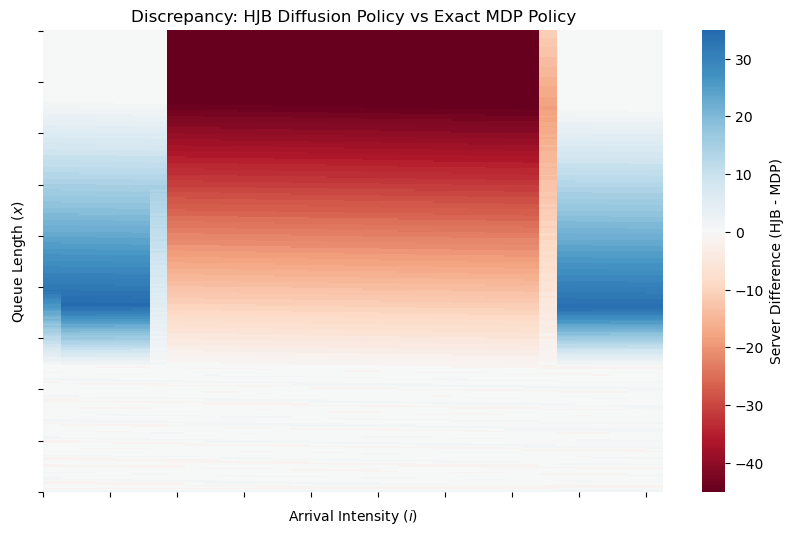

In [5]:
from scipy.interpolate import RegularGridInterpolator
import seaborn as sns

# ==========================================
# 6. Map HJB Policy to MDP State Space
# ==========================================
print("\nMapping continuous HJB policy to discrete MDP space...")

# Create a 2D interpolator for the HJB beta policy
# bounds_error=False and fill_value=None ensures that if the MDP state space 
# extends slightly beyond the HJB grid, it extrapolates using the nearest edge value.
beta_interpolator = RegularGridInterpolator((y_grid, u_grid), optimal_beta, 
                                            bounds_error=False, fill_value=None)

# Initialize the discrete HJB policy container
hjb_policy_2d = np.zeros((X_MAX + 1, K), dtype=int)

for x_idx in range(X_MAX + 1):
    for k_idx in range(K):
        i_val = I_grid[k_idx]
        
        # 1. State Mapping: (x, i) -> (y, u)
        y_val = (x_idx - (lambda_mean / mu)) / (lambda_mean ** scale_exp)
        u_val = (i_val - lambda_mean) / (lambda_mean ** scale_exp)
        
        # 2. Query the continuous beta* control
        beta_val = beta_interpolator((y_val, u_val))
        
        # 3. Action Mapping: beta* -> n
        n_val = (lambda_mean + beta_val * (lambda_mean ** scale_exp)) / mu
        
        # 4. Round to nearest physical server and clip to MDP constraints [0, N_MAX]
        n_rounded = int(np.round(n_val))
        hjb_policy_2d[x_idx, k_idx] = max(0, min(N_MAX, n_rounded))

print("Mapping complete.")

# ==========================================
# 7. Compare MDP Exact Policy vs HJB Heuristic
# ==========================================
# Calculate the discrepancy between the exact MDP and the HJB approximation
policy_difference = hjb_policy_2d - policy_2d
max_diff = np.max(np.abs(policy_difference))
mean_diff = np.mean(np.abs(policy_difference))

print(f"\nPolicy Comparison Metrics:")
print(f"Max Server Discrepancy: {max_diff} servers")
print(f"Mean Server Discrepancy: {mean_diff:.4f} servers")

# --- Plot the Discrepancy Heatmap ---
plt.figure(figsize=(10, 6))
ax = sns.heatmap(policy_difference, 
                 cmap="RdBu", 
                 center=0, 
                 cbar_kws={'label': 'Server Difference (HJB - MDP)'},
                 xticklabels=np.round(I_grid, 1))

# Clean up axes (showing every few ticks for readability)
ax.invert_yaxis()  # Put queue length 0 at the bottom
plt.title('Discrepancy: HJB Diffusion Policy vs Exact MDP Policy')
plt.xlabel('Arrival Intensity ($i$)')
plt.ylabel('Queue Length ($x$)')

# Show only a subset of x-ticks and y-ticks if the grid is large
num_ticks = 10
ax.set_xticks(np.linspace(0, K-1, num_ticks))
ax.set_yticks(np.linspace(0, X_MAX, num_ticks))

plt.show()

In [6]:
# --- HJB Policy Evaluation ---
policy = hjb_policy_2d.flatten()  # Flatten to match the MDP state indexing
# Extract transition matrix and cost vector for the CURRENT policy
P_pi = P_tilde[np.arange(S), policy, :]
C_pi = C_tilde[np.arange(S), policy]

# Construct (I - P) * V + gamma * 1 = C
M = np.eye(S) - P_pi

# Anchor the first state V(0) = 0 to solve for gamma
M[:, 0] = 1.0 

# Solve the linear system
sol = np.linalg.solve(M, C_pi)

# Extract discrete gamma and relative values
gamma_discrete = sol[0]
V = np.zeros(S)
V[1:] = sol[1:]

# Convert gamma back to continuous time
gamma_continuous_hjb = gamma_discrete * Phi
print(f"\nEstimated Long-Run Average Cost (Gamma) for HJB Policy: {gamma_continuous_hjb:.4f}")
# print absolute error compared to the MDP optimal gamma
print(f"Absolute Error: {abs(gamma_continuous_hjb - gamma_continuous):.4f}")


Estimated Long-Run Average Cost (Gamma) for HJB Policy: 1928.5034
Absolute Error: 1.2503


# Discrete-Time Simulation to Compute Long Run Average Cost

In [7]:
# ==========================================
# 6. Discrete-Time Simulation (Euler-Maruyama & Thinning)
# ==========================================
import time
import tqdm

def run_simulation(policy_2d, T_sim=10000, dt=0.001, burn_in=1000):
    print(f"\nStarting Discrete-Time Simulation...")
    print(f"Time Horizon (T) = {T_sim}, Time Step (dt) = {dt}, Burn-in = {burn_in}")
    
    start_time = time.time()
    
    # 1. Initial State
    X = 0
    I = lambda_mean
    
    # Tracking
    total_cost = 0.0
    steps = int(T_sim / dt)
    burn_in_steps = int(burn_in / dt)
    
    # Pre-compute SDE constants to speed up the loop
    sde_volatility_const = sigma * math.sqrt(lambda_mean**alpha)
    sqr_dt = math.sqrt(dt)
    
    for step in tqdm.tqdm(range(steps + burn_in_steps), desc="Simulating"):
        # --- A. Policy Lookup ---
        # Map continuous I(t) to the closest discrete grid index
        i_idx = int(round((I - I_min) / delta_i))
        i_idx = max(0, min(K - 1, i_idx))  # Clamp to grid limits to avoid OutOfBounds
        x_idx = min(X, X_MAX)
        
        # Get optimal action (number of servers)
        n = policy_2d[x_idx, i_idx]
        
        # --- B. Cost Accumulation ---
        if step >= burn_in_steps:
            q_len = max(X - n, 0)
            # Match the continuous-time expected cost rate from the MDP
            cost_rate = (c_s * n**2) + (h_cost * (q_len**p_power)) + (c_a * theta * q_len)
            total_cost += cost_rate * dt
            
        # --- C. Simulate Event Transitions over dt ---
        
        # 1. Arrivals via Thinning Method
        # Dynamically set the upper bound to handle occasional diffusion spikes
        I_bound = max(I, I_max) 
        
        # Step 1 of Thinning: Generate potential arrival
        if np.random.rand() < I_bound * dt:
            # Step 2 of Thinning: Accept according to actual intensity
            if np.random.rand() < (I / I_bound):
                X += 1
                
        # 2. Departures (Service + Abandonment)
        dep_rate = mu * min(X, n) + theta * max(0, X - n)
        if np.random.rand() < dep_rate * dt:
            X = max(0, X - 1)
            
        # --- D. Update Intensity I(t) via Euler-Maruyama ---
        drift = kappa * (lambda_mean - I) * dt
        diffusion = sde_volatility_const * math.sqrt(max(I, 0)) * sqr_dt * np.random.randn()
        
        I += drift + diffusion
        I = max(0, I) # Reflecting boundary at 0 to ensure non-negative intensity

    simulated_gamma = total_cost / T_sim
    
    print(f"Simulation completed in {time.time() - start_time:.2f} seconds.")
    return simulated_gamma

# Run the simulation
# Note: T_sim=10000 with dt=0.001 runs 10 million steps. 
# This takes roughly 10-15 seconds in standard Python.
sim_gamma = run_simulation(policy_2d, T_sim=50000, dt=0.005, burn_in=1000)
sim_gamma_hjb = run_simulation(hjb_policy_2d, T_sim=50000, dt=0.005, burn_in=1000)

print("-" * 40)
print(f"MDP Long-Run Average Cost:   {gamma_continuous:.4f}")
print(f"HJB Long-Run Average Cost:   {gamma_continuous_hjb:.4f}")
print(f"Simulated Long-Run Avg Cost: {sim_gamma:.4f}")
print(f"Simulated HJB Avg Cost:      {sim_gamma_hjb:.4f}")
print("-" * 40)


Starting Discrete-Time Simulation...
Time Horizon (T) = 50000, Time Step (dt) = 0.005, Burn-in = 1000


Simulating:   0%|          | 0/10200000 [00:00<?, ?it/s]

Simulating: 100%|██████████| 10200000/10200000 [01:44<00:00, 97194.20it/s]


Simulation completed in 104.95 seconds.

Starting Discrete-Time Simulation...
Time Horizon (T) = 50000, Time Step (dt) = 0.005, Burn-in = 1000


Simulating: 100%|██████████| 10200000/10200000 [01:45<00:00, 96823.00it/s]

Simulation completed in 105.35 seconds.
----------------------------------------
MDP Long-Run Average Cost:   1927.2531
HJB Long-Run Average Cost:   1928.5034
Simulated Long-Run Avg Cost: 1933.8278
Simulated HJB Avg Cost:      1910.7345
----------------------------------------
